### 1. Data Preparation:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.simplefilter('ignore')

In [3]:
df=pd.read_excel('heart_disease.xlsx',sheet_name='Heart_disease')

In [4]:
df.shape

(908, 13)

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


### 2. Exploratory Data Analysis (EDA):

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [7]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [8]:
#checkig missing values
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [9]:
df['oldpeak']=df['oldpeak'].fillna(df['oldpeak'].median())

In [10]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [11]:
#checking duplicates
df.duplicated().sum()

1

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.duplicated().sum()

0

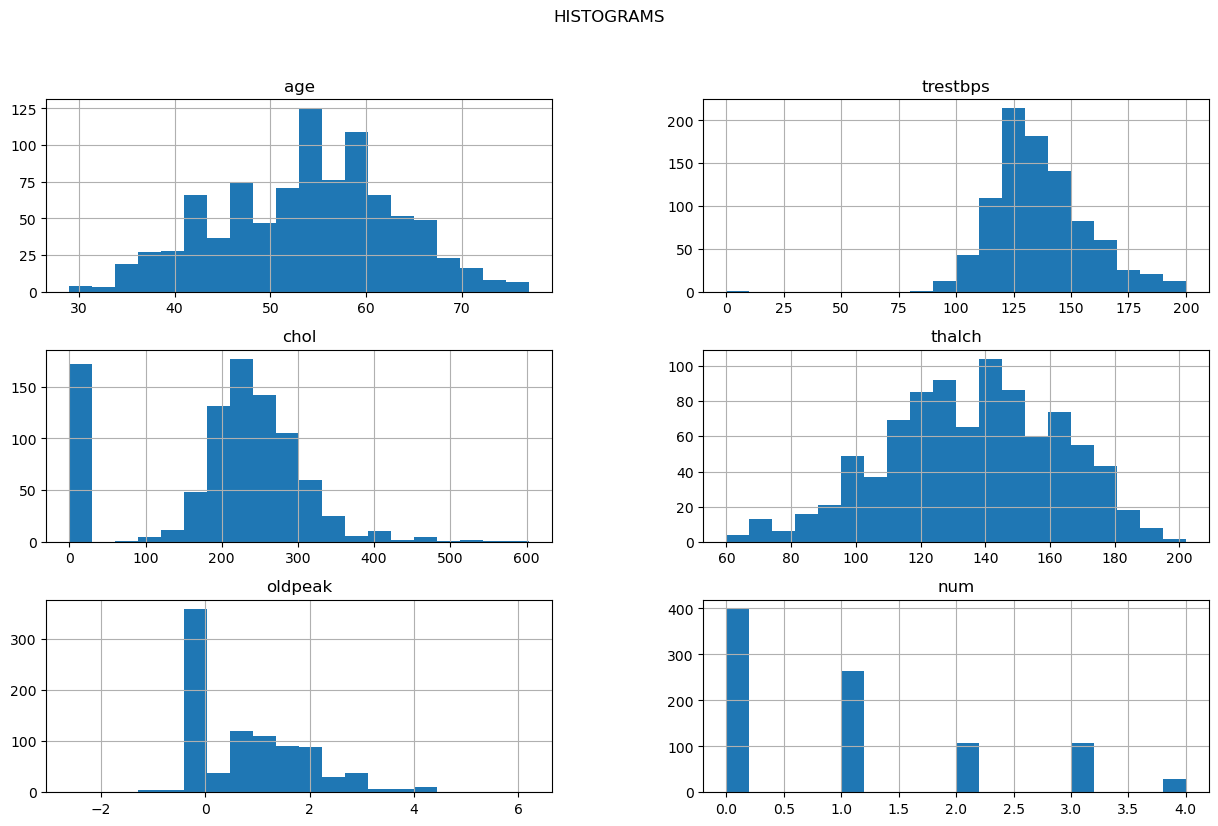

In [14]:
df.hist(bins=20,figsize=(15,9))
plt.suptitle("HISTOGRAMS")
plt.show()

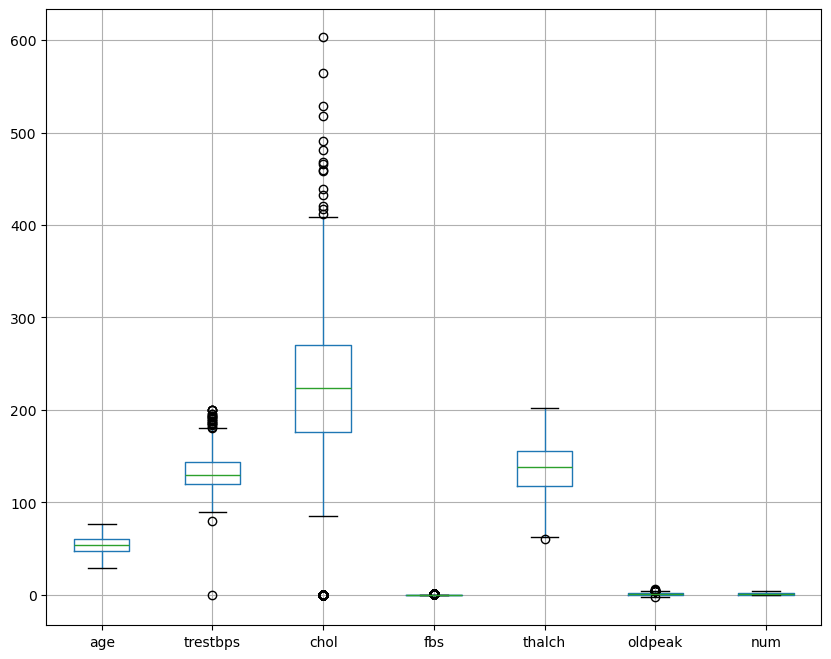

In [15]:
#checking outliers by using boxplot
plt.figure(figsize=(10,8))
df.boxplot()
plt.show()

In [16]:
#outlier capping 
def outlier_capping(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)
    iqr=q3-q1
    lower_extreme=q1-1.5*iqr
    high_extreme=q3+1.5*iqr
    df[column]=df[column].apply(lambda x: lower_extreme if x<lower_extreme else high_extreme if x>high_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

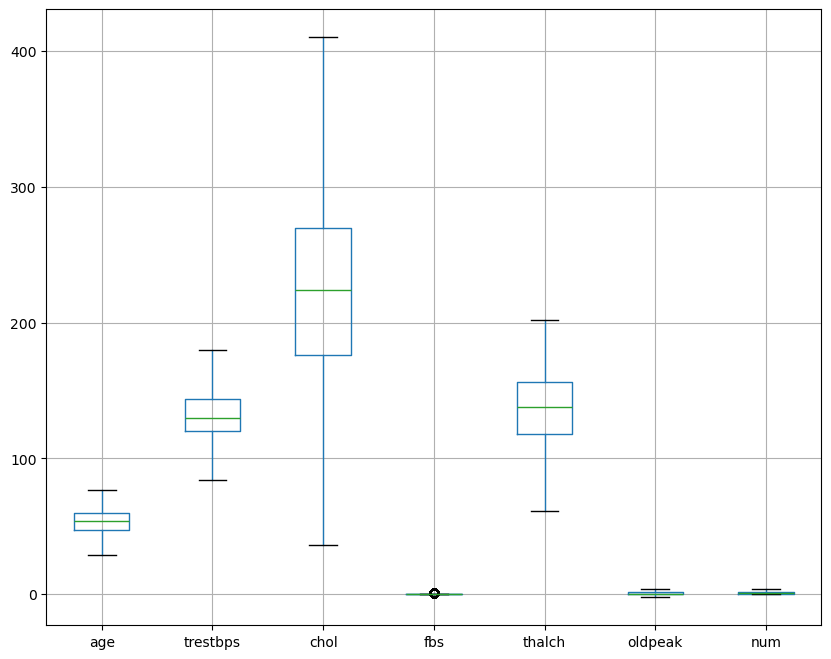

In [17]:
plt.figure(figsize=(10,8))
df.boxplot()
plt.show()

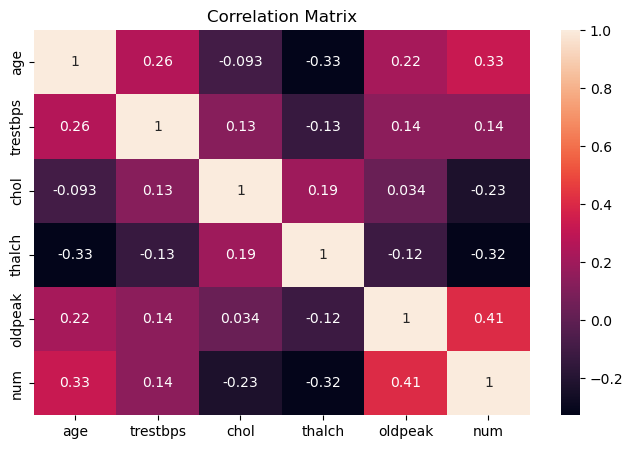

In [18]:
# Correlation matrix for only numerical columns

plt.figure(figsize=(8,5))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Correlation Matrix")

plt.show()

### 3. Feature Engineering:

In [19]:
#converting bool to int
df['fbs'] = df['fbs'].astype(int)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 907 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       907 non-null    int64  
 1   sex       907 non-null    object 
 2   cp        907 non-null    object 
 3   trestbps  907 non-null    float64
 4   chol      907 non-null    float64
 5   fbs       907 non-null    int32  
 6   restecg   907 non-null    object 
 7   thalch    907 non-null    float64
 8   exang     907 non-null    object 
 9   oldpeak   907 non-null    float64
 10  slope     907 non-null    object 
 11  thal      907 non-null    object 
 12  num       907 non-null    int64  
dtypes: float64(4), int32(1), int64(2), object(6)
memory usage: 95.7+ KB


In [21]:
from sklearn.preprocessing import LabelEncoder

In [22]:
label_enc = LabelEncoder()

In [23]:
cat_cols = df.select_dtypes(include='object').columns

In [24]:
for col in cat_cols:
    df[col] = df[col].astype(str)   # convert all values to string
    df[col] = label_enc.fit_transform(df[col])

In [25]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145.0,233.0,1,0,150.0,1,2.3,0,0,0
1,41,1,1,135.0,203.0,0,1,132.0,1,0.0,1,0,0
2,57,1,0,140.0,192.0,0,1,148.0,1,0.4,1,0,0
3,52,1,3,118.0,186.0,0,0,190.0,1,0.0,1,0,0
4,57,1,0,110.0,201.0,0,1,126.0,3,1.5,1,0,0


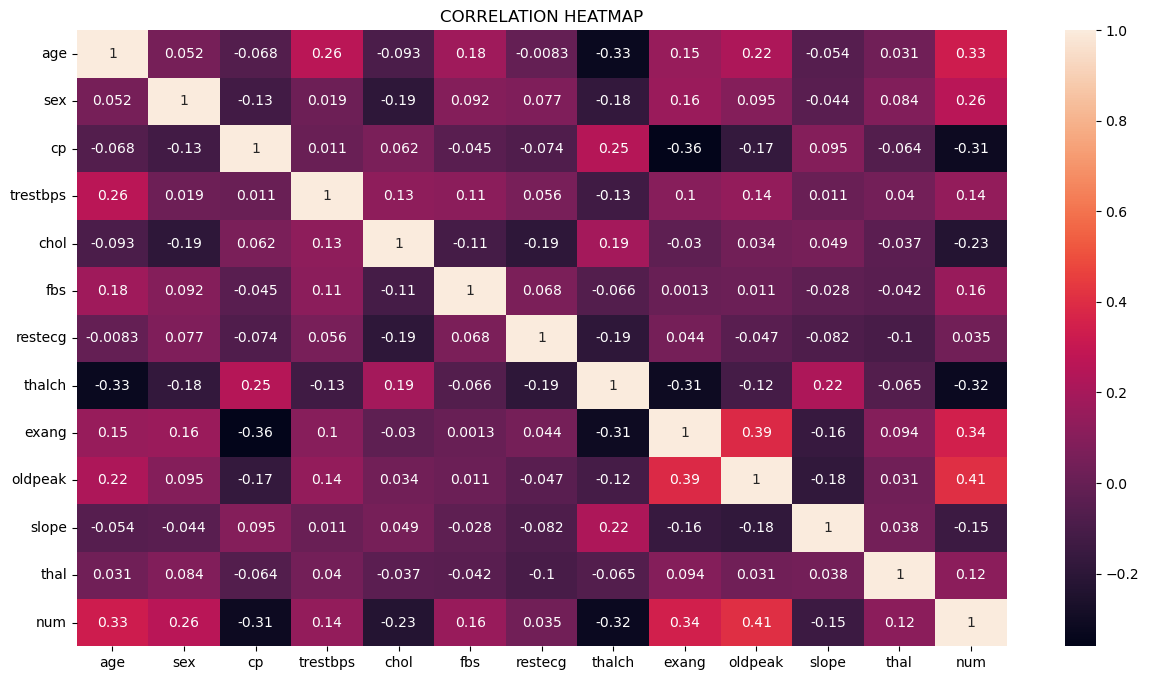

In [26]:
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(),annot=True)
plt.title('CORRELATION HEATMAP')
plt.show()

### 4. Decision Tree Classification:

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

In [28]:
features = df.drop('num',axis=1)
target = df[['num']]

In [29]:
x_train,x_test,y_train,y_test=train_test_split(features,target,test_size=0.2,random_state=50)

In [30]:
model=DecisionTreeClassifier(criterion='entropy',max_depth=3)
model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

In [31]:
y_pred=model.predict(x_test)

In [32]:
# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred,average='weighted') #
recall = recall_score(y_test, y_pred,average='weighted')
f1 = f1_score(y_test, y_pred,average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Accuracy: 0.521978021978022
Precision: 0.419708053140889
Recall: 0.521978021978022
F1-Score: 0.465249686561162


In [33]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.66      0.82      0.73        72
           1       0.45      0.55      0.49        55
           2       0.00      0.00      0.00        29
           3       0.24      0.32      0.27        19
           4       0.00      0.00      0.00         7

    accuracy                           0.52       182
   macro avg       0.27      0.34      0.30       182
weighted avg       0.42      0.52      0.47       182



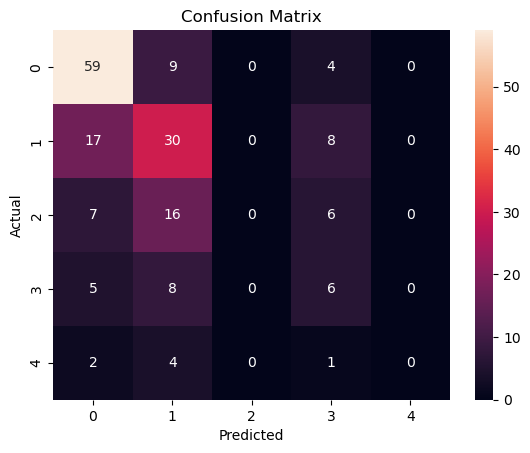

In [34]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### 5. Hyperparameter Tuning:

In [35]:
from sklearn.model_selection import GridSearchCV

In [36]:
params={'criterion':['gini','entropy'],'max_depth':[1,2,3,4,5,6,7],'splitter':['random','best'],    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]}

In [37]:
grid=GridSearchCV(model,params)

In [38]:
grid.fit(x_train,y_train)

GridSearchCV(estimator=DecisionTreeClassifier(criterion='entropy', max_depth=3),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['random', 'best']})

In [39]:
grid.best_params_

{'criterion': 'gini',
 'max_depth': 3,
 'min_samples_leaf': 4,
 'min_samples_split': 5,
 'splitter': 'random'}

In [40]:
model2=DecisionTreeClassifier(criterion='gini',max_depth=3,splitter='random',min_samples_leaf= 4,min_samples_split= 2)

In [41]:
model2.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=4, splitter='random')

In [42]:
y_pred1=model2.predict(x_test)

### 6. Model Evaluation and Analysis:

In [43]:
# Model Evaluation
accuracy = accuracy_score(y_test, y_pred1)
precision = precision_score(y_test, y_pred1,average='weighted') #
recall = recall_score(y_test, y_pred1,average='weighted')
f1 = f1_score(y_test, y_pred1,average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Accuracy: 0.5164835164835165
Precision: 0.4545414726171122
Recall: 0.5164835164835165
F1-Score: 0.44004367513192827


In [44]:
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.64      0.78      0.70        72
           1       0.40      0.67      0.50        55
           2       0.50      0.03      0.06        29
           3       0.00      0.00      0.00        19
           4       0.00      0.00      0.00         7

    accuracy                           0.52       182
   macro avg       0.31      0.30      0.25       182
weighted avg       0.45      0.52      0.44       182



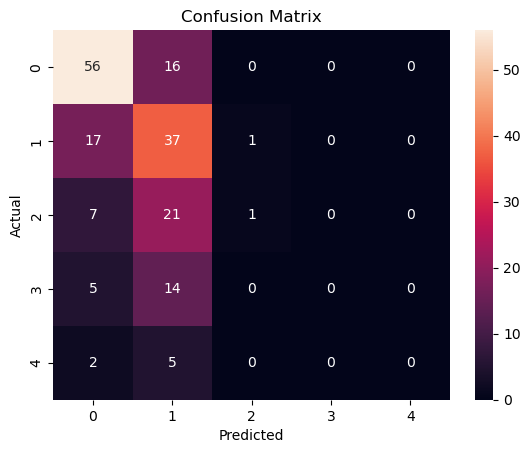

In [45]:
cm1 = confusion_matrix(y_test, y_pred1)

sns.heatmap(cm1, annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

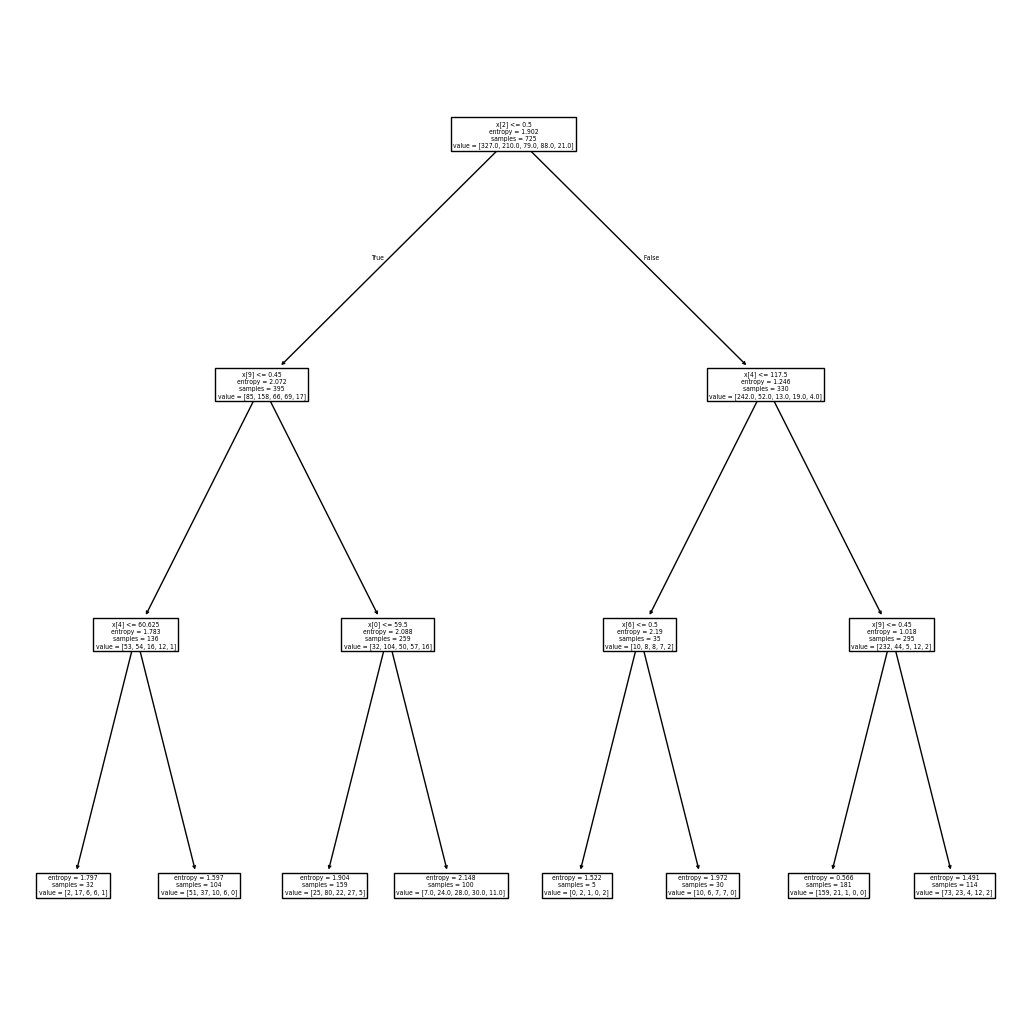

In [46]:
# Visualize the decision tree structure for model1 
plt.figure(figsize=(13,13))
tree.plot_tree(model)
plt.show()

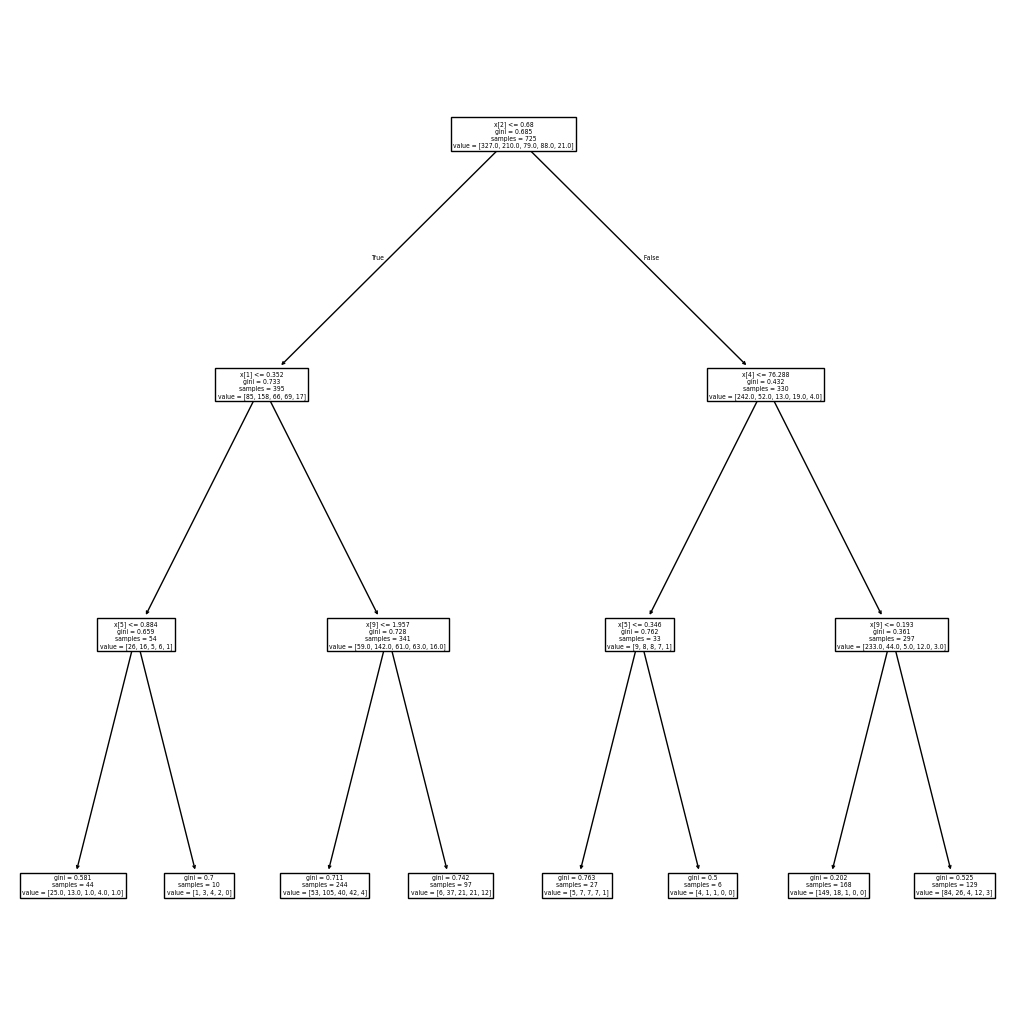

In [47]:
# Visualize the decision tree structure for model2
plt.figure(figsize=(13,13))
tree.plot_tree(model2)
plt.show()

### Interview Questions:

### 1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

### 2. What is the difference between the Label encoding and One-hot encoding?

#### answer: Label Encoding:

#### One-Hot Encoding:

In [ ]:
One-Hot Encoding converts each category into separate binary columns.
Each column contains only 0 and 1 values.
It is mainly used for nominal categorical data where there is no order.
This method prevents models from assuming category relationships.
However, it increases the number of columns and memory usage.